## Error Analysis: Nairobi House Prices

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [189]:
# load the dataset
df = pd.read_csv('data/nairobi_house_prices.csv')
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


## Data Cleaning and Preprocessing

In [190]:
# Explore the dataset: shape, missing values, duplicates, and numeric summaries
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)

Shape: (204, 7)

Missing values:
 Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

Duplicates: 30

Data Types:
 Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object


In [191]:
# remove duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [192]:
# impute the missing values with the median for numeric columns and mode for categorical columns
for column in df.columns:
    if df[column].dtype == 'str':
        df[column] = df[column].fillna(df[column].mode()[0])
    elif df[column].dtype in ['int64', 'float64']:
        df[column] = df[column].fillna(df[column].median())

df.isnull().sum()

Price           0
propertyType    0
Location        0
Bedroom         0
bathroom        0
House size      0
Land size       0
dtype: int64

In [225]:
df.head(20)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,150,0.50
1,30000000.0,Vacant Land,Karen,3.0,2.0,150,0.50
2,325000000.0,Vacant Land,Westlands,3.0,2.0,150,0.50
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,150,0.50
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,230,0.50
5,300000000.0,Townhouse,Runda,6.0,6.0,150,0.50
6,160000000.0,Townhouse,Runda,4.0,4.0,150,0.50
7,9500000.0,Apartment,Kilimani,2.0,2.0,105,0.50
8,150000000.0,Townhouse,Thigiri,4.0,4.0,150,0.50
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,280,0.50


In [194]:
# convert land size and House size to numeric columns
df['Land size'] = pd.to_numeric(
    df['Land size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df['House size'] = pd.to_numeric(
    df['House size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# clean Price: strip "Ksh", commas, spaces, then convert to numeric
df['Price'] = (
    df['Price']
    .str.replace(r'[^\d.]', '', regex=True)  # keep only digits and decimal points
    .astype(float)
)

df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,150,0.5
1,30000000.0,Vacant Land,Karen,3.0,2.0,150,0.5
2,325000000.0,Vacant Land,Westlands,3.0,2.0,150,0.5
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,150,0.5
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,230,0.5
5,300000000.0,Townhuse,Runda,6.0,6.0,150,0.5
6,160000000.0,Townhouse,Runda,4.0,4.0,150,0.5
7,9500000.0,Apartment,Kilimani,2.0,2.0,105,0.5
8,150000000.0,Townhouse,Thigiri,4.0,4.0,150,0.5
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,280,0.5


In [195]:
# Standardise propertyType labels and inspect the distribution of each type
df['propertyType'] = df['propertyType'].replace({
    'Townhuse': 'Townhouse',
    'Town house': 'Townhouse'
})

df['propertyType'].value_counts()

propertyType
Apartment              92
Townhouse              65
Vacant Land            15
Commercial Property     1
Industrial Property     1
Name: count, dtype: int64

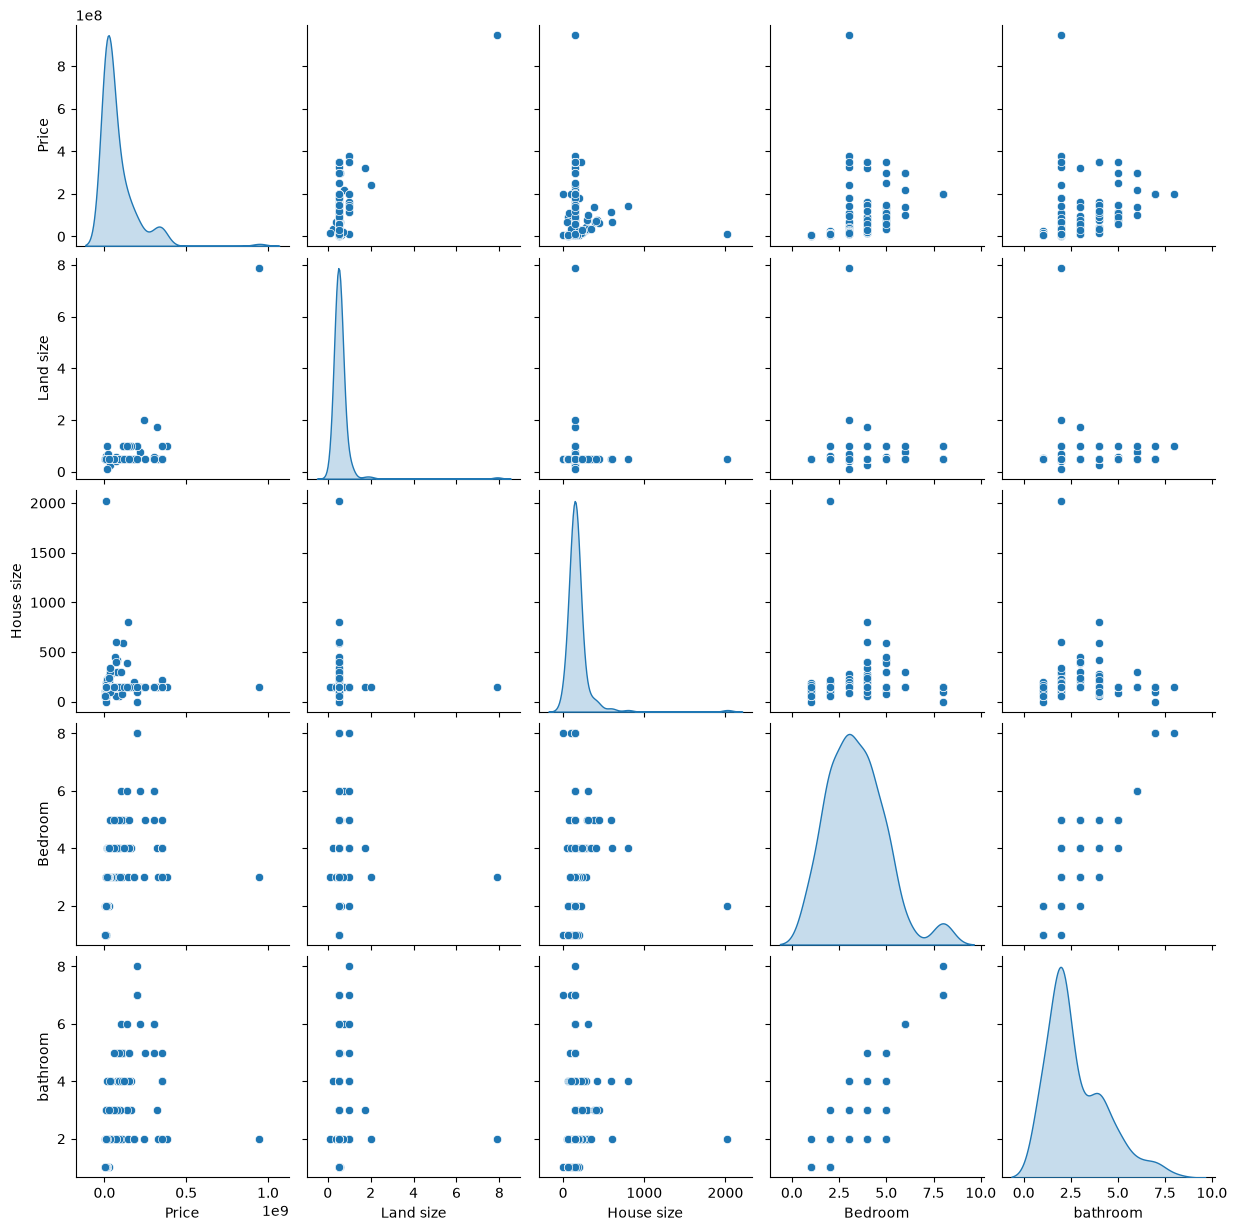

In [196]:
# plot a pairplot to visualize the relationships between numeric features and the target variable (Price)
sns.pairplot(
    df[['Price', 'Land size', 'House size', 'Bedroom', 'bathroom']],
    diag_kind='kde'   # or 'hist' for histograms instead of KDE curves
)
plt.show()

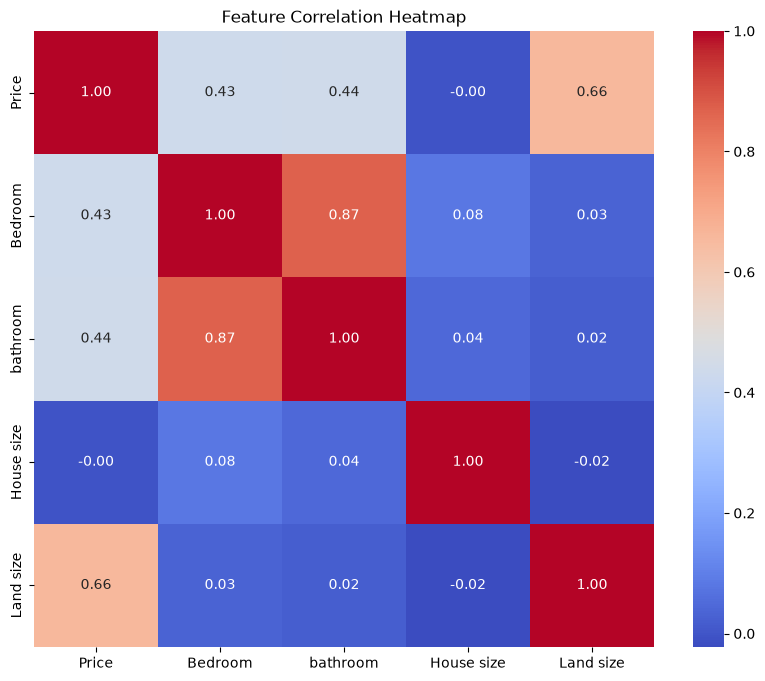

In [197]:
# feature correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

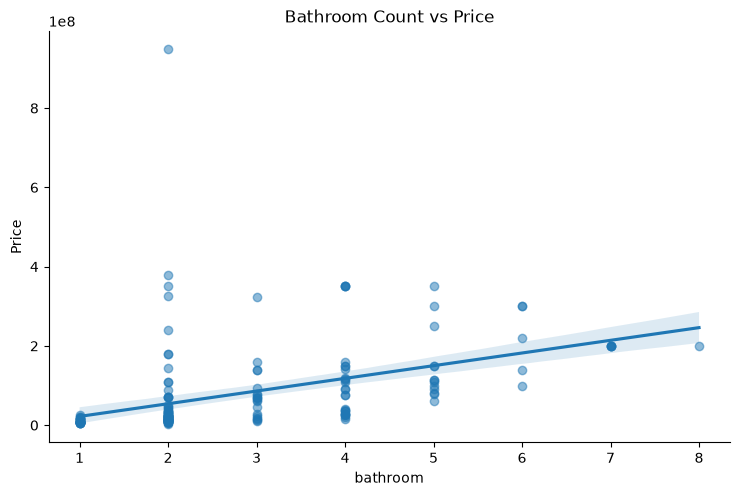

In [198]:
# check linearity of the relationship between features and target variable using sns.lmplot
sns.lmplot(x='bathroom', y='Price', data=df, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("Bathroom Count vs Price")
plt.show()

In [199]:
# split the dataset into features and target variable
X = df.drop(columns=['Price'])
y = df['Price']

# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['propertyType', 'Location'], drop_first=True)

In [200]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [201]:
# model training and evaluation with linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](33,)","[ -607278.31, 6172212.63, 871.83,..., 4982730.95,13599522.08, 36940980.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](33,)","['Bedroom','bathroom','House size',...,'Location_Thome', 'Location_Waithaka','Location_Westlands']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.111e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,30


In [202]:
# scores
scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')

print("Cross-validated R^2 scores:", scores)
print("Mean R^2 score:", np.mean(scores))

Cross-validated R^2 scores: [0.51345301 0.82059516 0.52953787 0.48331458 0.43880191]
Mean R^2 score: 0.5571405078057428


In [203]:
# learning curve for linear regression
train_sizes, train_scores, val_scores = learning_curve(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

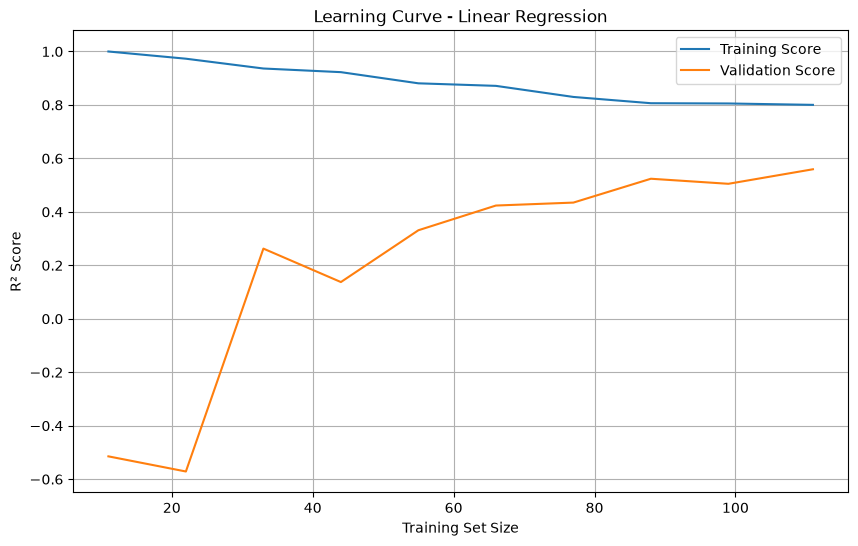

In [204]:
# plot the learning curve - linear regression
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

In [205]:
# add complexity Polynomial Regression
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])

scores = cross_val_score(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Polynomial Regression R² scores:", scores)
print("Polynomial (degree=1) R²:", scores.mean())

Polynomial Regression R² scores: [0.51345301 0.82059516 0.52953787 0.48331458 0.43880191]
Polynomial (degree=1) R²: 0.5571405078057323


In [206]:
# add complexity Polynomial Regression degree=2
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

scores = cross_val_score(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Polynomial Regression R² scores:", scores)
print("Polynomial (degree=2) R²:", scores.mean())

Polynomial Regression R² scores: [-2.06741553 -0.00947436  0.61098911  0.49960822  0.55799768]
Polynomial (degree=2) R²: -0.08165897660266586


In [207]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

from scipy.stats import randint, uniform
param_dist = {
    'poly__degree': randint(1, 4),
    'ridge__alpha': uniform(0.01, 10)
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters (Random Search):")
print(random_search.best_params_)

print("Best CV Score:", random_search.best_score_)

Best Parameters (Random Search):
{'poly__degree': 2, 'ridge__alpha': np.float64(1.5699452033620265)}
Best CV Score: 0.6808320202386499


## Error Analysis

In [208]:
best_model = random_search.best_estimator_

In [209]:
y_pred = best_model.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.7538506918621777


In [210]:
errors = y_test - y_pred

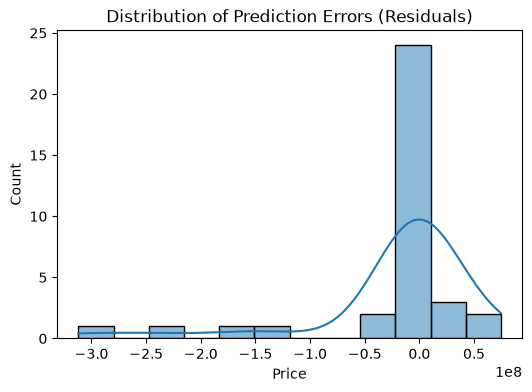

In [211]:
plt.figure(figsize=(6,4))
sns.histplot(errors, kde=True)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.show()

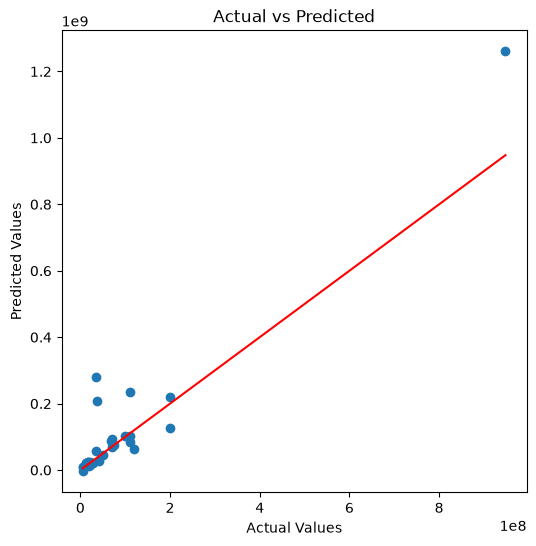

In [212]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

In [213]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Abs_Error": np.abs(errors)
})

results.sort_values(by="Abs_Error", ascending=False).head(10)

,Actual,Predicted,Error,Abs_Error
76,948000000.0,1.260035e+09,-3.120351e+08,3.120351e+08
12,35000000.0,2.802218e+08,-2.452218e+08,2.452218e+08
27,38000000.0,2.081314e+08,-1.701314e+08,1.701314e+08
172,110000000.0,2.358598e+08,-1.258598e+08,1.258598e+08
46,200000000.0,1.252937e+08,7.470626e+07,7.470626e+07
182,120000000.0,6.291325e+07,5.708675e+07,5.708675e+07
126,110000000.0,8.438648e+07,2.561352e+07,2.561352e+07
194,35000000.0,5.772031e+07,-2.272031e+07,2.272031e+07
34,70000000.0,9.238685e+07,-2.238685e+07,2.238685e+07
47,68000000.0,8.751148e+07,-1.951148e+07,1.951148e+07


In [222]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred,
    "Abs_Error": np.abs(y_test.values - y_pred)
})

In [223]:
results_with_features = X_test.copy()
results_with_features["Actual"] = y_test.values
results_with_features["Predicted"] = y_pred
results_with_features["Error"] = y_test.values - y_pred
results_with_features["Abs_Error"] = np.abs(y_test.values - y_pred)

In [224]:
worst_cases = results_with_features.sort_values(by="Abs_Error", ascending=False).head(10)
worst_cases

,Bedroom,bathroom,House size,Land size,propertyType_Commercial Property,propertyType_Industrial Property,propertyType_Townhouse,propertyType_Vacant Land,Location_Karen,Location_Kiambu Road,...,Location_Runda,Location_Syokimau,Location_Thigiri,Location_Thome,Location_Waithaka,Location_Westlands,Actual,Predicted,Error,Abs_Error
76,3.0,2.0,150,7.90,False,False,False,True,False,False,...,False,False,False,False,False,False,948000000.0,1.260035e+09,-3.120351e+08,3.120351e+08
12,4.0,4.0,150,0.25,False,False,True,False,False,False,...,True,False,False,False,False,False,35000000.0,2.802218e+08,-2.452218e+08,2.452218e+08
27,4.0,4.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,38000000.0,2.081314e+08,-1.701314e+08,1.701314e+08
172,5.0,4.0,75,0.50,False,False,True,False,False,False,...,True,False,False,False,False,False,110000000.0,2.358598e+08,-1.258598e+08,1.258598e+08
46,8.0,7.0,1,0.50,False,False,True,False,False,False,...,True,False,False,False,False,False,200000000.0,1.252937e+08,7.470626e+07,7.470626e+07
182,4.0,4.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,120000000.0,6.291325e+07,5.708675e+07,5.708675e+07
126,5.0,2.0,150,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,110000000.0,8.438648e+07,2.561352e+07,2.561352e+07
194,4.0,4.0,95,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,35000000.0,5.772031e+07,-2.272031e+07,2.272031e+07
34,3.0,2.0,150,0.56,False,False,False,True,False,False,...,False,False,False,False,False,False,70000000.0,9.238685e+07,-2.238685e+07,2.238685e+07
47,4.0,3.0,399,0.50,False,False,True,False,False,False,...,False,False,False,False,False,False,68000000.0,8.751148e+07,-1.951148e+07,1.951148e+07


## Model Explainability with LIME and SHAP

So far we focused on *how well* the model predicts. Here we ask a different question: **why does it predict what it does?** We use two popular tools:

- **LIME** explains a **single prediction** by fitting a simple, readable model around that one house.
- **SHAP** tells us how much **every feature contributes to every prediction**, and lets us see the overall picture across the whole test set.

Both are "model agnostic" - they work on any model without looking inside it.

### 1. LIME: Why does the model quote this price for one house?

We pick the **first house in the test set** and ask LIME to explain its predicted price. LIME returns the features that pushed the prediction **up** (green) or **down** (red), ranked by how much they matter.

In [226]:
import lime
from lime.lime_tabular import LimeTabularExplainer

# Set up LIME using the training data as background
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression',
)

# Explain the first test house
house_idx = 0
exp = explainer_lime.explain_instance(
    data_row=np.array(X_test.iloc[house_idx]),
    predict_fn=best_model.predict,
    num_features=8,
)

# Print the actual and predicted price for context
print(f"Actual Price   : KSh {y_test.iloc[house_idx]:,.0f}")
print(f"Predicted Price: KSh {best_model.predict(X_test.iloc[[house_idx]])[0]:,.0f}")

# Readable summary of what pushed the price up or down
print("\nFeature contributions")
print(f"{'Feature':<32}{'Effect (KSh)':>15}  Direction")
print('-' * 62)
for feat, weight in sorted(exp.as_list(), key=lambda x: -abs(x[1])):
    direction = 'push UP' if weight > 0 else 'push DOWN'
    print(f"{feat:<32}{weight:>+15,.0f}  {direction}")

Actual Price   : KSh 20,668,800
Predicted Price: KSh 18,496,196

Feature contributions
Feature                            Effect (KSh)  Direction
--------------------------------------------------------------
Location_Runda <= 0.00             -204,722,184  push DOWN
Location_Muthaiga <= 0.00          -177,616,401  push DOWN
propertyType_Vacant Land <= 0.00   -163,161,813  push DOWN
propertyType_Commercial Property <= 0.00   -123,451,531  push DOWN
Location_Kitisuru <= 0.00           -74,269,416  push DOWN
propertyType_Townhouse <= 0.00      -70,355,740  push DOWN
Location_Thigiri <= 0.00            -52,533,652  push DOWN
Location_Ongata Rongai <= 0.00      +52,035,074  push UP


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


**Brief insight - LIME:** For this particular house, most large features are the *location dummies* that this house does **not** belong to (each has a value of 0), so they push the predicted price **down** - e.g. it is not in **Runda** or **Muthaiga**, the two most expensive suburbs, each worth roughly 170M-200M+ KSh on a price tick. The single feature that pushes the price **up** for this house is its actual location, **Ongata Rongai**. In short, the model mostly "starts high" (expecting a Nairobi list price) and then adjusts down for the cheaper area this house is really in. This is a **local** explanation - it changes house by house and only applies to this one row, not the model in general.

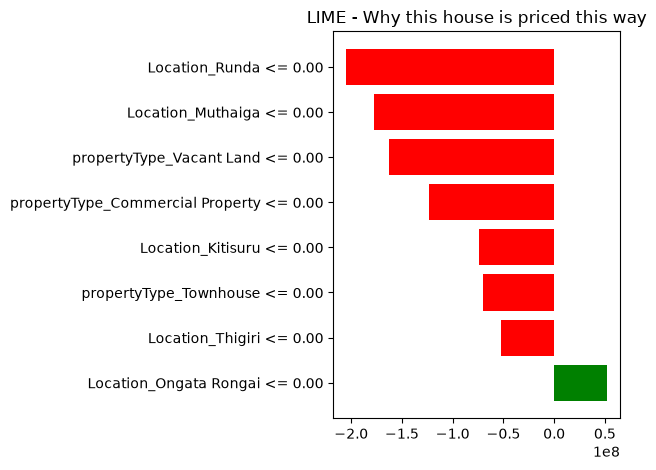

In [227]:
# Visual version of the same LIME explanation
fig = exp.as_pyplot_figure()
plt.title('LIME - Why this house is priced this way')
plt.tight_layout()
plt.show()

In the bar chart, bars pointing **right** increase the predicted price and bars pointing **left** decrease it. The longer the bar, the larger that feature's effect on this one prediction.

### 2. SHAP: Which features matter most overall?

SHAP computes a contribution ("SHAP value") for every feature on **every** test house. Averaging the absolute values gives a **global feature importance** plot.

Background dataset has 139 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=139 when initializing the masker.
/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_52625/661127209.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns.tolist(), plot_type='bar')


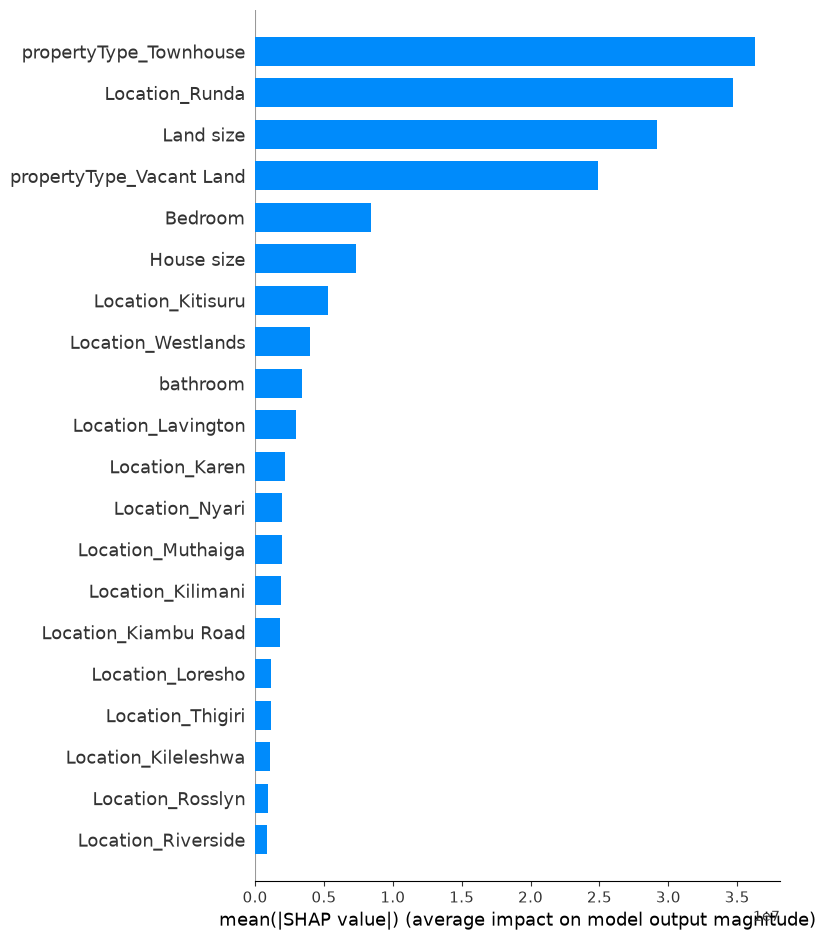

In [228]:
import shap

# Use an independent masker so SHAP can explain any model, including the pipeline
masker = shap.maskers.Independent(X_train.astype(float))
explainer_shap = shap.Explainer(best_model.predict, masker)
shap_values = explainer_shap(X_test.astype(float))

# Global importance: average absolute SHAP value per feature
shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns.tolist(), plot_type='bar')

**Brief insight - SHAP bar plot:** This is the *global* view - it averages each feature's contribution over **all** test houses. Here the biggest drivers of the predicted price are **property type** (*Townhouse*, *Vacant Land*) and **location** (*Runda*) and **Land size**. Location is still very important, but once we control for everything, the type of property and the size of the land dominate how much the model quotes. These are the features the model leans on most overall.

### 3. SHAP: How do features push prices up or down?

The **beeswarm plot** adds direction and feature values to the same SHAP values. Each dot is one house. Red = high feature value, blue = low.

/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_52625/276412153.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns.tolist())


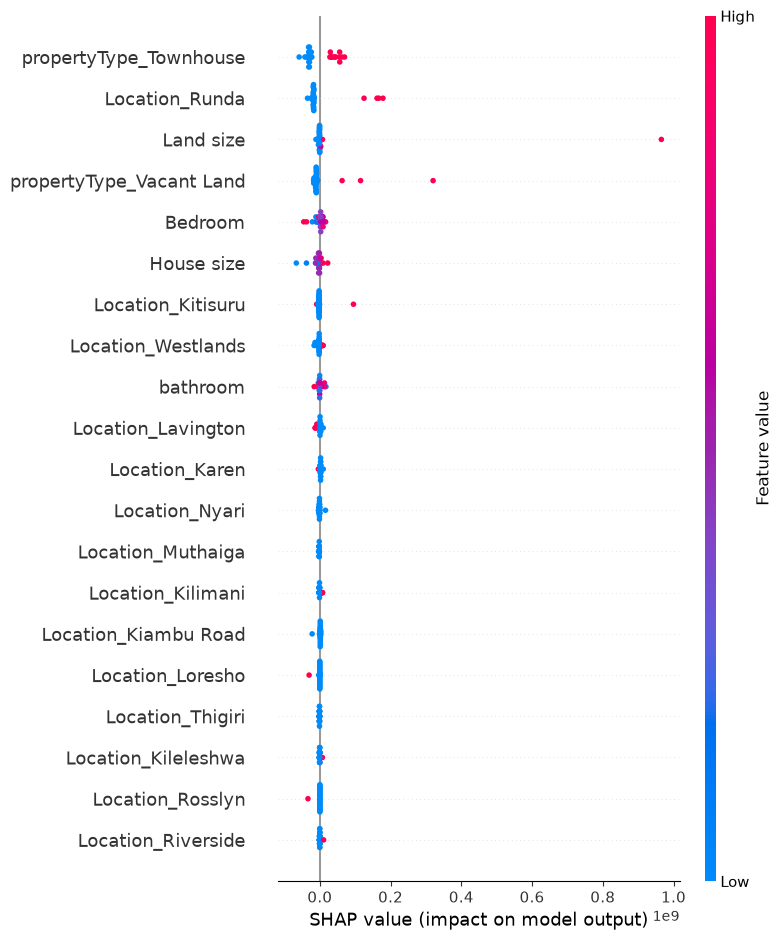

In [229]:
# Beeswarm: shows direction AND magnitude of each feature's effect
shap.summary_plot(shap_values, X_test.astype(float), feature_names=X_test.columns.tolist())

**Brief insight - SHAP beeswarm:** If the red dots (high feature values) sit on the **right**, higher values of that feature push the predicted price **up**; if they sit on the left, higher values push it **down**. This makes it easy to spot non-obvious relationships, e.g. a feature where both very low and very high values raise the price.

### 4. SHAP: Explaining one house step by step

The **waterfall plot** shows how the model moves from the average prediction (base value) to this house's final prediction, one feature at a time.

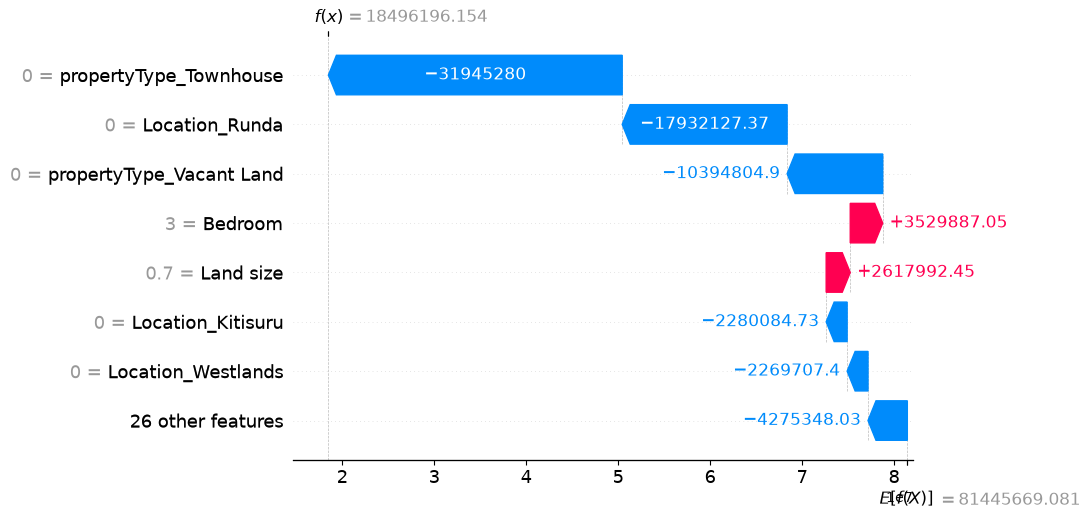

<Figure size 640x480 with 0 Axes>

In [230]:
# Explain the same first test house as LIME, so we can compare
shap.plots.waterfall(shap_values[0], max_display=8)
plt.tight_layout()
plt.show()

**Brief insight - SHAP waterfall:** Starting from the base value (the **average predicted price**, around 81M KSh), each arrow adds or subtracts a feature's effect. For this house the model moves **downwards**: it is not a *Townhouse*, not a *Vacant Land* plot and not in *Runda*, so those big positive price effects do not apply. Smaller boosts come from having **3 Bedrooms** and **Land size**. The final value is the model's predicted price for this house - matching what LIME said for the same house (location/type effects dominate).

### Summary: LIME vs SHAP

| | **LIME** | **SHAP** |
|---|---|---|
| **Scope** | One prediction at a time (local) | Global (all predictions) + local |
| **Best for** | Explaining a single house/price | Ranking features & direction across the dataset |
| **Output** | A small interpretable model around one point | Shapley contributions (game-theory based) |
| **Speed** | Fast per-example | Slower (needs a background set) |

Both tools agree on the big picture: **property type, location and land size** drive the model's price predictions. LIME shows the reasoning for a single house, while SHAP gives the ranking across the whole test set. Together they confirm the model is picking up real market signals rather than noise.